In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from DiffusionModel import *

import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle as pkl

from tqdm import tqdm
import os
from copy import deepcopy
import time

from scipy.spatial import Delaunay

In [2]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'cpu'
device

'cpu'

In [13]:
def plot_state(vertices,state,simplices,vmin=300,vmax=900,save_path=None):
    """
    plot the predicted temperature state of the part
    """
    
    state = state + 273.15
    fig = plt.figure(figsize=(8,7))
    
    if len(simplices[0]) == 3:
        triangles = simplices
    else:
        triangles = np.concatenate([
                    simplices[:,(0,1,2)],
                    simplices[:,(0,1,3)],
                    simplices[:,(0,2,3)],
                    simplices[:,(1,2,3)],
        ])
    
    ax = fig.add_subplot(1,1,1,projection='3d')
    colors = np.array([state[simplex.tolist()].mean() for simplex in triangles])
    plot = ax.plot_trisurf(vertices[:,0],vertices[:,1],vertices[:,2], triangles=triangles,cmap='turbo', alpha=.1,vmin=vmin,vmax=vmax)
    plot.set_array(colors)
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlim(0,30)
    ax.set_ylim(0,30)
    ax.set_zlim(0,15)
    ax.view_init(20, 160)

    
    # ax = fig.add_subplot(1,2,2,projection='3d')
    # verts = ax.scatter(vertices[:,0],vertices[:,1],vertices[:,2],c=state,cmap='jet',vmin=vmin,vmax=vmax)
    # ax.xaxis.set_ticklabels([])
    # ax.yaxis.set_ticklabels([])
    # ax.zaxis.set_ticklabels([])
    
    cb_ax = fig.add_axes([.91,.25,.015,.5])
    cbar = fig.colorbar(plot,orientation='vertical',cax=cb_ax)    
    cbar.set_alpha(1)
    cbar.draw_all()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', format='svg')
    plt.show()
    
def plot_surface(surface_data,vmin=300,vmax=900,save_path=None):
    """
    plot surface data from thermal images
    """
    
    surface_data = surface_data + 273.15
    
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(1,1,1)
    image = ax.imshow(np.flip(surface_data,axis=1), interpolation='spline36', cmap='turbo',
                       origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', format='svg')
    plt.show()
    
def plot_surface_state(vertices,state, vmin=300, vmax=900, save_path=None):
    """
    plot predicted surface temperature
    """
    state = state + 273.15
    
    surface_z = vertices[:,2].max()
    surface_state = [(vertex[:2],temperature) for vertex,temperature in zip(vertices,state) if vertex[2] == surface_z]
    vertices, temperatures = zip(*surface_state)
    triangles = Delaunay(vertices)
    vertices, temperatures = list(vertices), list(temperatures)
    
    vertices = np.flip(vertices,axis=1)
    
    vertices[:,0] = 30-vertices[:,0]
    
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(1,1,1)
    
    cmap = mpl.colormaps['turbo']
    triangulation = mpl.tri.Triangulation(vertices[:,0], vertices[:,1], triangles.simplices)
    ax.tripcolor(triangulation, temperatures, shading='gouraud', cmap='turbo', vmin=vmin,vmax=vmax)
    # ax.scatter(vertices[:,0], vertices[:,1], c=temperatures, cmap='turbo', vmin=vmin, vmax=vmax)
    ax.set_xlim(0,30)
    ax.set_ylim(0,30)
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', format='eps')
    plt.show()

In [4]:
def transfer_state(vertices_source, state_source, vertices_target, space_dim=(100,100,100000)):
    """
    transfer the temperatures in the source graph to the target vertices at the same spatial location 
    (for passing from the graph for one layer to the graph for the next layer)
    """
    
    device = state_source.device
    indices = torch.stack([vertices_source[:,0].type(torch.int32),
                           vertices_source[:,1].type(torch.int32),
                           (1000*vertices_source[:,2]).type(torch.int32)])

    space_temperatures = torch.sparse_coo_tensor(indices,state_source.to_dense(),space_dim,device=device)
    state_target = torch.stack([space_temperatures[int(x),int(y),int(1000*z)] for x,y,z in vertices_target])
    return state_target


def calculate_energy(distribution, density, classes):
    """
    calculate the potential energy of the heat state (i.e. the second moment of the temperature over the domain)
    """
    
    boundary_order = classes.sum(dim=1)
    weights = (1/density)*torch.pow(2.,-boundary_order)
    weights = weights/weights.sum()
    energy = torch.dot(distribution.square(),weights) - torch.dot(distribution,weights).square()
    return energy

def calculate_heat(distribution, density, classes, dissipation=None):
    """
    calculate the total thermal energy 
    """
    
    boundary_order = classes.sum(dim=1)
    weights = (1/density)*torch.pow(2.,-boundary_order)
    heat = torch.dot(distribution,weights)
    if dissipation is None:
        return heat
    dissipation_heat = torch.dot(dissipation,weights)
    return heat, dissipation_heat
    
def fit_model(model, 
              depths_iters=[(2,10), (5,10), (10,10), (25,10), (50,10), (100,10)], # pairs of training depth and number of training iterations for the depth 
              initial_state=None, 
              lambd=1, 
              alpha_conn=1e-1, 
              alpha_diss=1e-1, 
              alpha_weight=1e-1,
              alpha_energy=1., 
              alpha_heat=1., 
              alpha_max_min=1.,
              save_best=False,
              save_path='diffusion_model.pt'):
    
    n_layers = depths_iters[-1][0] # total number of layers in the final part
    
    optim = torch.optim.Adam(model.parameters(),lr=1e-6, betas=(.5,.999))
    loss_fn = nn.MSELoss()
    
    history = []
    start_time = int(time.time())
    
    weight_reg_vec = torch.tensor([1/np.math.factorial(j) for j in range(1,model.k+1)],dtype=torch.float32, device=device) # for calculating the weight regularization loss
    
    save_depth = False
    
    # increase the number of layers used for training, as later layers are sensitive to the hidden state obtained from the model predictions, and
    # thus require a relatively well-trained model in order to produce reasonable predictions
    for dix, (depth, depth_iterations) in enumerate(depths_iters):
        print('depth:', depth)
        
        if dix==(len(depths_iters)-1):
            save_depth = True
            best_loss = np.inf
        
        if depth>=25:
            ditr = range(depth_iterations)
            pbar=True
        else:
            ditr = tqdm(range(depth_iterations))
            pbar=False

        for depth_iter in ditr:
            
            # initialize values for accumulating the losses for the current training depth
            depth_avg_loss = 0.
            depth_fwd_loss = 0.
                
            if pbar:
                itr = tqdm(range(depth))
            else:
                itr = range(depth)
                
            for layer in itr:
                
                data = load_data_layer(layer)
                
                # initialize values for accumulating losses for the current layer
                layer_loss = 0.
                layer_const_loss = 0.
                layer_conn_loss = 0.
                layer_diss_loss = 0.
                layer_energy = 0.
                layer_avg_steps = 0.

                if layer==0:
                    if initial_state is not None:
                        layer_init_state = initial_state
                    else:
                        layer_init_state = model.boundary_value * torch.ones((data[0].shape[0],),dtype=torch.float32,device=device)
                
                # determine the initial heat state for the layer by transfering the final state of the previous layer, taking into account the
                # diffusion in the time passed during recoating    
                else: 
                    time_delta=(data[4][0]-prev_last_time)/1000
                    state = model(prev_distances, prev_densities, prev_boundary, state, time_delta).detach().view(-1)
                    layer_init_state = transfer_state(prev_vertices,state,data[0])
                
                
                prev_vertices = data[0]
                prev_distances = data[1]
                prev_densities = data[2]
                prev_boundary = data[3]
                prev_last_time = data[4][-1]

                state = layer_init_state
                
                # sample the evaluation time-steps (either random or n-step)
                
                # jumps = np.random.poisson(lambd,len(data[5])) + 1
                # eval_ixs = np.cumsum(jumps)
                # eval_ixs = eval_ixs[np.where(eval_ixs<len(data[5]))].tolist()
                # if eval_ixs[0] > 0:
                #     eval_ixs = [0,] + eval_ixs
                
                eval_ixs = np.arange(0,len(data[5]),lambd).tolist()
                if eval_ixs[-1] < len(data[5])-1:
                    eval_ixs.append(len(data[5])-1)
                
                X = [(data[1], data[2], data[3], data[5][eval_ixs[i]], (data[4][eval_ixs[i+1]]-data[4][eval_ixs[i]])/1000, data[6][eval_ixs[i+1]]) for i in range(len(eval_ixs)-1)]
                Y = [data[5][eval_ixs[i]] for i in range(1,len(eval_ixs))]
                
                for (distances, densities, boundary, surface_temp, time_delta, laser_dist), y in zip(X,Y):
                    
                    optim.zero_grad()
                    
                    # assign the surface temperature values
                    state[surface_temp.indices()[0]] = 0.
                    state = state + surface_temp.to_dense()
                    
                    # evaluate the model and loss function
                    pred, conn_loss, diss_loss, diss_vec, laser_heat = model(distances, densities, boundary, state, time_delta, laser_dist, fit=True)
                    pred_loss = loss_fn(pred[y.indices()].view(-1,1),y.values().view(-1,1))
                    
                    # calculate the regularizing loss functions
                    pred = pred - laser_heat
                    weight_loss = (torch.dot(model.weights/model.weights[0],torch.tensor([np.math.factorial(i) for i in range(1,model.k+1)], dtype=torch.float32,device=device))-torch.ones_like(model.weights)).square().mean()
                    neighbor_temp = (torch.sign(distances).to_dense() * pred.view(-1).to_dense())
                    max_principle_violation = (torch.relu(pred.view(-1)-neighbor_temp.max(dim=1).values)).where(torch.logical_and(pred>state,boundary.sum(dim=1)==0),torch.zeros_like(pred)).square().mean()
                    min_principle_violation = (torch.relu(neighbor_temp.min(dim=1).values-pred.view(-1))).where(torch.logical_and(pred>state,boundary.sum(dim=1)==0),torch.zeros_like(pred)).square().mean()
                    energy_violation = torch.relu(
                                calculate_energy(pred,densities,boundary) # energy of prediction 
                               -calculate_energy(state,densities,boundary) # energy of previous state
                             )
                    heat, heat_diss = calculate_heat(pred,densities,boundary, dissipation=diss_vec.squeeze())
                    total_heat_diff = ((heat-heat_diss)/state.sum()-1).square()
                    
                    # assemble the total loss
                    loss = pred_loss + \
                           alpha_conn * conn_loss + \
                           alpha_diss * diss_loss + \
                           alpha_energy * energy_violation + \
                           alpha_heat * total_heat_diff + \
                           alpha_max_min * (max_principle_violation + min_principle_violation)
                    
                    # optimization step
                    loss.backward()
                    optim.step()    
                    
                    # log the loss values
                    push_fwd_loss = loss_fn(state[y.indices()].view(-1,1),y.values().view(-1,1))
                    layer_loss += pred_loss.item()/(len(eval_ixs)-1)
                    layer_const_loss += push_fwd_loss.item()/(len(eval_ixs)-1)
                    layer_conn_loss += conn_loss.item()/(len(eval_ixs)-1)
                    layer_diss_loss += diss_loss.item()/(len(eval_ixs)-1)
                    layer_energy += (energy_violation + total_heat_diff + max_principle_violation + min_principle_violation).item()/(len(eval_ixs)-1)

                    # use the predicted state for the next time-step
                    state = pred.detach().clip(0,1e3).view(-1)

                layer_avg_steps += len(eval_ixs)-1
                
                if pbar:
                    itr.set_postfix({'l_T':layer_loss, 
                                     'rel':(layer_const_loss-layer_loss)/layer_const_loss, 
                                     'l_reg':(layer_conn_loss+layer_diss_loss), 
                                     'l_w': weight_loss.item(),
                                     'l_E': layer_energy,
                                     't_min':state.min().item(), 
                                     't_max':state.max().item()})
                
                depth_avg_loss += layer_loss
                depth_fwd_loss += layer_const_loss
            if pbar:
                print(depth_avg_loss/depth,(depth_fwd_loss-depth_avg_loss)/depth_fwd_loss)
            else:
                ditr.set_postfix({'l_T':depth_avg_loss/depth, 'rel':(depth_fwd_loss-depth_avg_loss)/depth_fwd_loss})
            if save_depth and depth_avg_loss < best_loss:
                best_loss = depth_avg_loss
                print('saving model state.')
                model.save(save_path, compiled=True, override=True)
                
        plot_state(data[0].detach().numpy(), state.detach().numpy(),data[7], save_path=f'plots/depth_{depth}_plot{dix}.svg')
        print('parameters:')
        print(model.weights)
        print(model.diss_model.coefs)

    return history

In [5]:
model = DiffusionModel() # DiffusionModel.load('heat_model_py7.pt')
sum(p.numel() for p in model.parameters() if p.requires_grad)

87563

depth: 2


100%|█████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.16it/s, l_T=79, rel=-.000543]


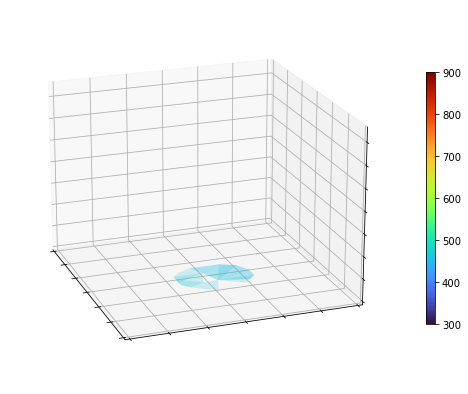

parameters:
Parameter containing:
tensor([0.0106, 0.0044, 0.0022], requires_grad=True)
Parameter containing:
tensor([-0.9991, -0.9991, -1.0000], requires_grad=True)
depth: 5


100%|██████████████████████████████████████████████████████████████| 10/10 [00:25<00:00,  2.55s/it, l_T=80.4, rel=-.007]


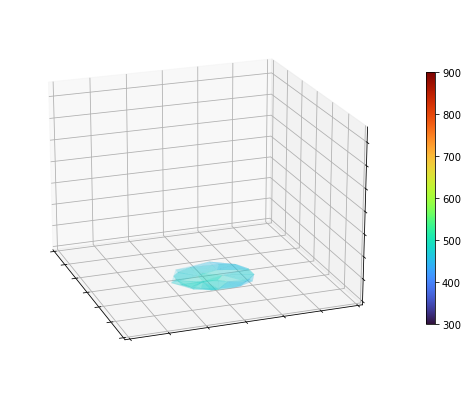

parameters:
Parameter containing:
tensor([0.0108, 0.0044, 0.0022], requires_grad=True)
Parameter containing:
tensor([-0.9975, -0.9973, -0.9975], requires_grad=True)
depth: 10


100%|████████████████████████████████████████████████████████████| 10/10 [01:00<00:00,  6.03s/it, l_T=79.6, rel=0.00371]


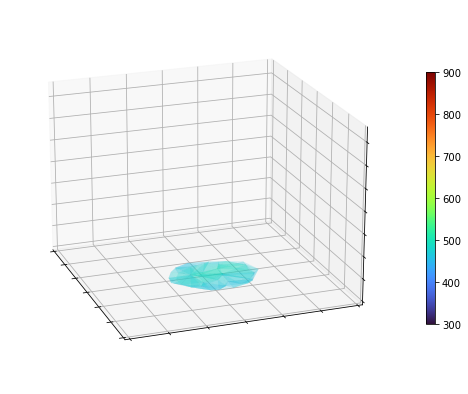

parameters:
Parameter containing:
tensor([0.0110, 0.0046, 0.0017], requires_grad=True)
Parameter containing:
tensor([-0.9941, -0.9932, -0.9929], requires_grad=True)
depth: 25


100%|█████████| 25/25 [00:17<00:00,  1.41it/s, l_T=71.7, rel=0.01, l_reg=2.56, l_w=2.94, l_E=0.22, t_min=178, t_max=244]


87.14163198741835 0.0046397458899895576


100%|███████| 25/25 [00:16<00:00,  1.50it/s, l_T=71.6, rel=0.0118, l_reg=2.55, l_w=2.77, l_E=0.22, t_min=178, t_max=243]


86.97994954439025 0.006486535695358438


...

86.81288103137238 0.00839484695575879


100%|████████| 25/25 [00:18<00:00,  1.35it/s, l_T=71.5, rel=0.0137, l_reg=2.5, l_w=2.03, l_E=0.22, t_min=178, t_max=239]


86.80181846322543 0.008521207231447121


100%|████████| 25/25 [00:16<00:00,  1.49it/s, l_T=71.4, rel=0.0138, l_reg=2.5, l_w=1.95, l_E=0.22, t_min=178, t_max=239]


86.79142763428075 0.008639894682013542


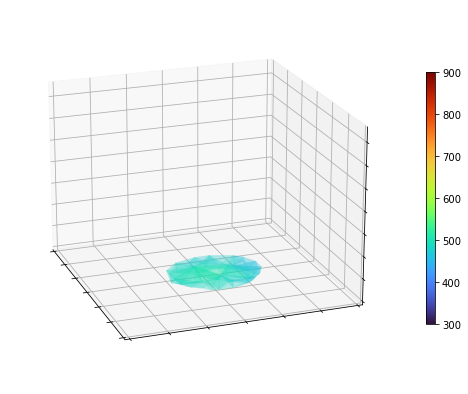

parameters:
Parameter containing:
tensor([0.0120, 0.0044, 0.0013], requires_grad=True)
Parameter containing:
tensor([-0.9852, -0.9822, -0.9814], requires_grad=True)
depth: 50


100%|████████| 50/50 [00:43<00:00,  1.15it/s, l_T=45.9, rel=0.0179, l_reg=133, l_w=1.77, l_E=81.2, t_min=178, t_max=244]


74.73189374690335 0.010620389029497985


100%|████████| 50/50 [00:44<00:00,  1.13it/s, l_T=45.9, rel=0.0181, l_reg=133, l_w=1.65, l_E=81.2, t_min=178, t_max=244]


74.69406009736328 0.01112127077605629


...

74.58106843037808 0.012617173608430962


100%|████████| 50/50 [00:43<00:00,  1.16it/s, l_T=45.8, rel=0.0197, l_reg=133, l_w=1.08, l_E=81.2, t_min=178, t_max=244]


74.564681005673 0.01283412761650724


100%|████████| 50/50 [00:43<00:00,  1.16it/s, l_T=45.8, rel=0.0199, l_reg=133, l_w=1.01, l_E=81.2, t_min=178, t_max=244]


74.5486085075051 0.013046912295008097


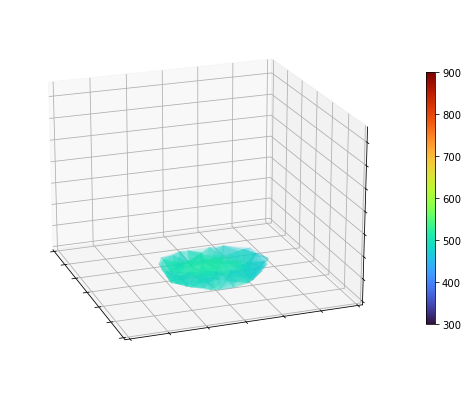

parameters:
Parameter containing:
tensor([0.0137, 0.0037, 0.0011], requires_grad=True)
Parameter containing:
tensor([-0.9664, -0.9587, -0.9567], requires_grad=True)
depth: 100


100%|████| 100/100 [02:35<00:00,  1.56s/it, l_T=34.3, rel=0.0189, l_reg=20.4, l_w=0.895, l_E=5.09, t_min=187, t_max=247]


62.46707590115554 0.013997545776503981
saving model state.


100%|█████| 100/100 [02:43<00:00,  1.64s/it, l_T=34.3, rel=0.019, l_reg=20.4, l_w=0.794, l_E=5.09, t_min=187, t_max=246]


62.447493330524054 0.014306644008238079
saving model state.


...

62.339407264378934 0.016012712764443205
saving model state.


100%|███| 100/100 [02:34<00:00,  1.54s/it, l_T=34.3, rel=0.0188, l_reg=20.2, l_w=0.334, l_E=5.08, t_min=187, t_max=243]


62.321487551767085 0.016295563856148203
saving model state.


100%|███| 100/100 [02:29<00:00,  1.49s/it, l_T=34.3, rel=0.0187, l_reg=20.2, l_w=0.292, l_E=5.07, t_min=187, t_max=243]


62.303306638380306 0.016582537833411893
saving model state.


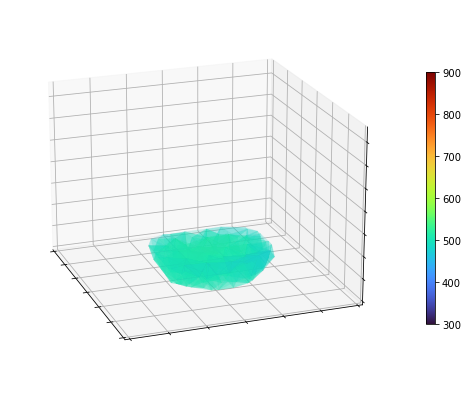

parameters:
Parameter containing:
tensor([0.0159, 0.0030, 0.0004], requires_grad=True)
Parameter containing:
tensor([-0.9214, -0.9030, -0.8982], requires_grad=True)


In [6]:
hist = fit_model(model, save_best=True)

In [14]:
def develop_layers(model,n_layers=500,print_layers=[5,10,25,50,100,150,200,250,300,350,400,450,500],boundary_value=124.9, use_data=None):
    """
    evaluate the model and visualize the predicted heat states
    """
    state = None
    history = []
    itr = tqdm(range(n_layers))
    for layer in itr:
        data = load_data_layer(layer)
        
        if layer==0:
            layer_init_state = boundary_value * torch.ones((data[0].shape[0],),dtype=torch.float32,device=device)
        else:
            time_delta=(data[4][0]-prev_last_time)/1000
            state = model(prev_distances, prev_densities, prev_boundary, state, time_delta).detach().view(-1)
            layer_init_state = transfer_state(prev_vertices,state,data[0])
        prev_vertices = data[0]
        prev_distances = data[1]
        prev_densities = data[2]
        prev_boundary = data[3]
        prev_last_time = data[4][-1]
        
        state = layer_init_state
        
        eval_ixs = np.arange(0,len(data[5]),1).tolist()
        if eval_ixs[-1] < len(data[5])-1:
            eval_ixs.append(len(data[5])-1)

        X = [(data[1], data[2], data[3], data[5][eval_ixs[i]], (data[4][eval_ixs[i+1]]-data[4][eval_ixs[i]])/1000, data[6][eval_ixs[i+1]]) for i in range(len(eval_ixs)-1)]
        Y = [data[5][eval_ixs[i]] for i in range(1,len(eval_ixs))]

        layer_pred_quality = 0.
        for (distances, densities, boundary, surface_temp, time_delta, laser_dist), y in zip(X,Y):
            if use_data is None or use_data[layer]:
                state[surface_temp.indices()[0]] = 0.
                state = state + surface_temp.to_dense()
            
            pred = model(distances, densities, boundary, state, time_delta, laser_dist)
            
            pred_true = torch.stack([((state-pred)[surface_temp.indices()[0]]),
                                        ((state-y)[surface_temp.indices()[0]])])
            pred_quality = torch.corrcoef(pred_true)[1,0]
            pred_quality = torch.nan_to_num(pred_quality).item()
            layer_pred_quality += pred_quality/(len(data[5])-1)
            
            state = pred.detach().clip(0,1e3).view(-1)
        
        history.append(layer_pred_quality)
        itr.set_postfix({'corr':layer_pred_quality})
        if (layer+1) in print_layers:
            plot_state(data[0].detach().numpy(), state.detach().numpy(),data[7], save_path=f'plots/layer_{layer+1}_same_range.svg')
            layer_temp = load_surface_temperatures(layer)[-1]
            plot_surface(layer_temp, save_path=f'plots/surface_data_layer_{layer+1}.svg')
            plot_surface_state(data[0].detach().numpy(), state.detach().numpy(), save_path=f'plots/surface_layer_{layer+1}.eps')
            
            
    return history

  1%|▌                                                                     | 4/500 [00:00<00:40, 12.15it/s, corr=0.402]

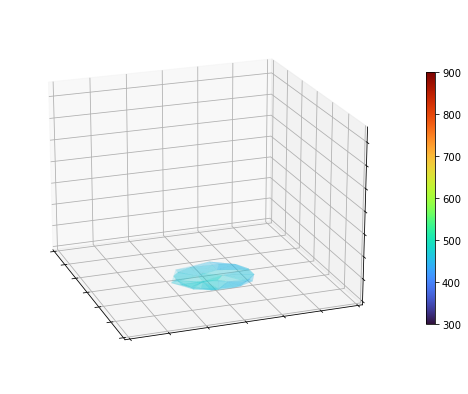

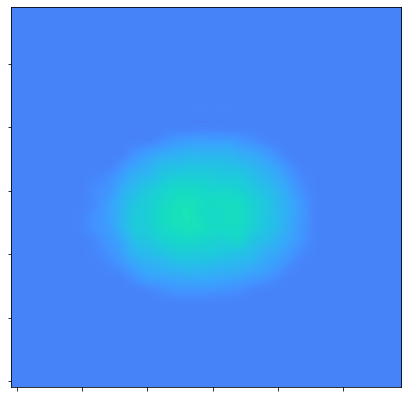

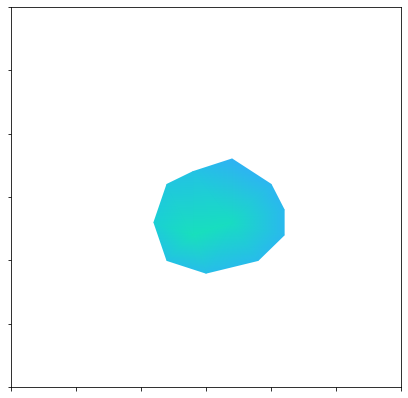

  2%|█                                                                     | 8/500 [00:01<01:20,  6.12it/s, corr=0.361]

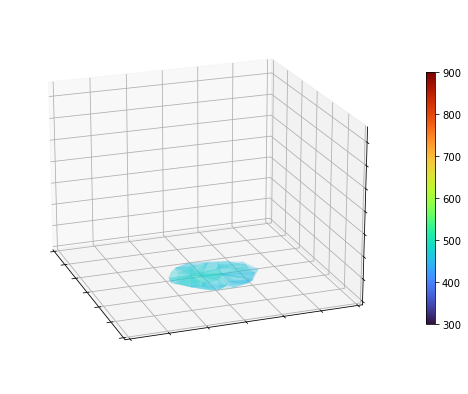

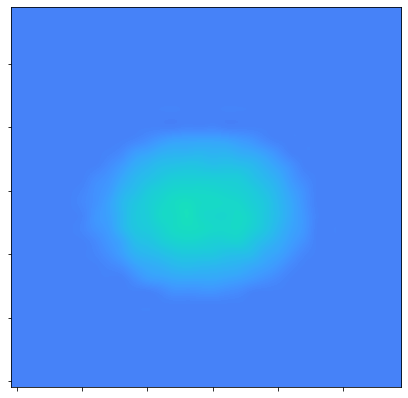

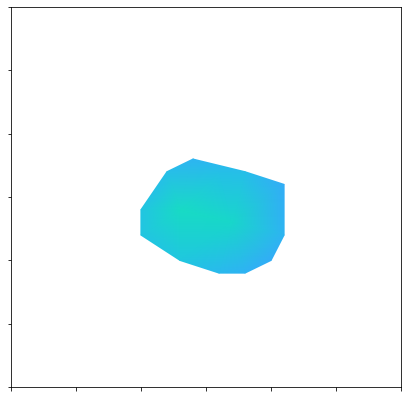

  5%|███▎                                                                  | 24/500 [00:03<00:53,  8.96it/s, corr=0.36]

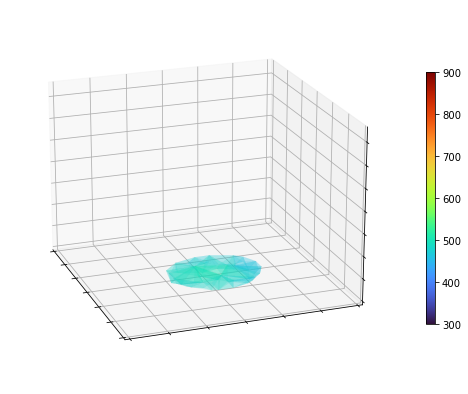

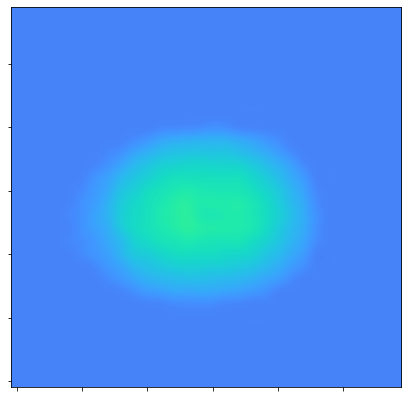

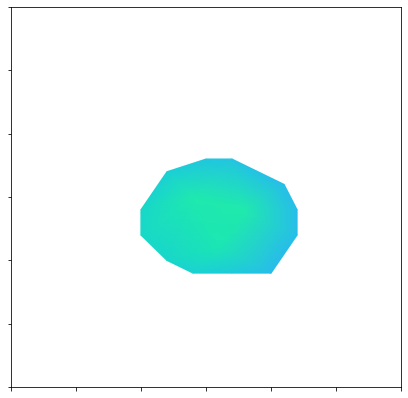

 10%|██████▊                                                              | 49/500 [00:07<00:54,  8.35it/s, corr=0.435]

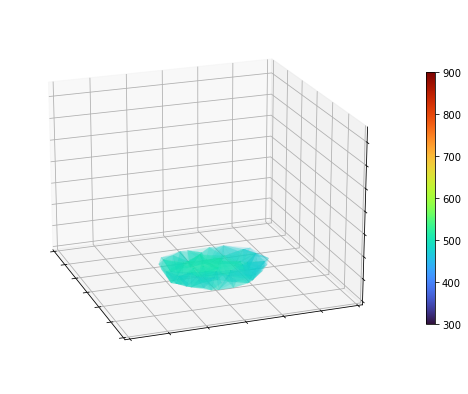

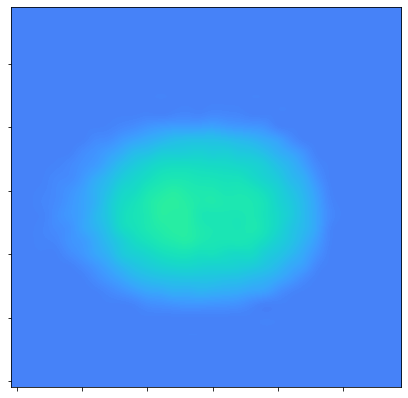

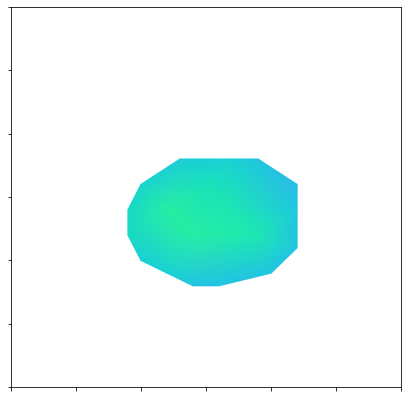

 20%|█████████████▋                                                       | 99/500 [00:16<01:32,  4.33it/s, corr=0.361]

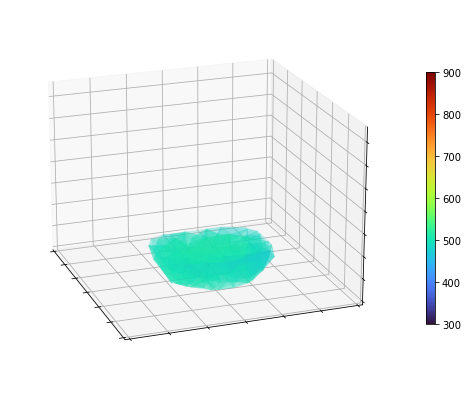

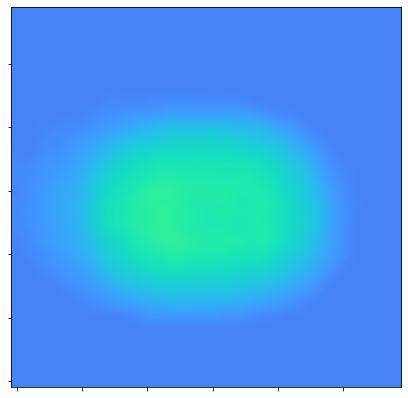

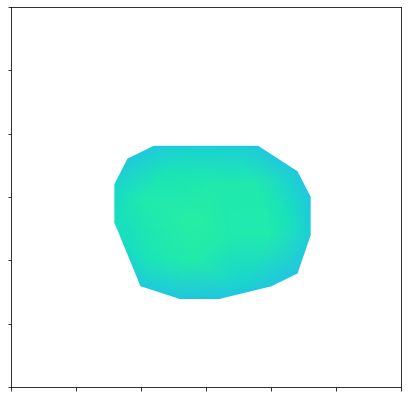

 30%|████████████████████▎                                               | 149/500 [00:31<02:11,  2.67it/s, corr=0.314]

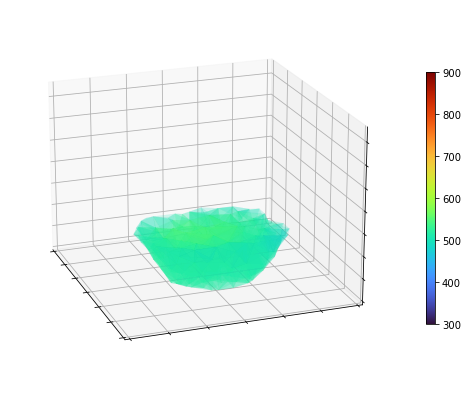

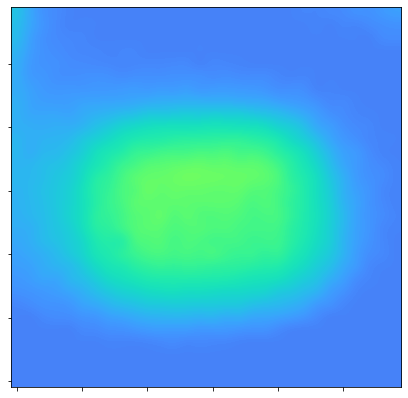

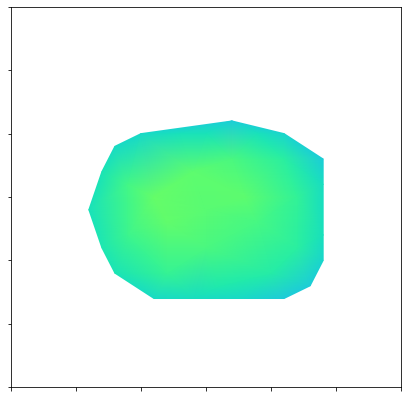

 40%|███████████████████████████                                         | 199/500 [00:53<02:08,  2.34it/s, corr=0.353]

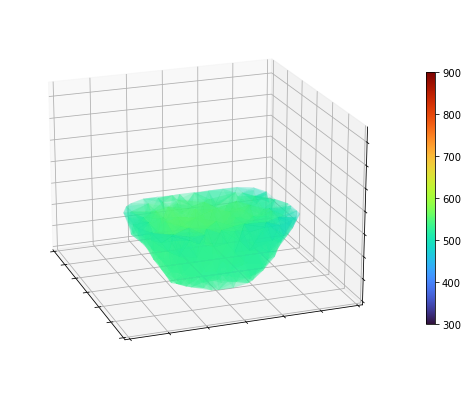

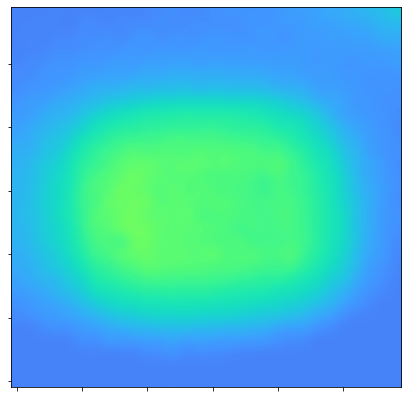

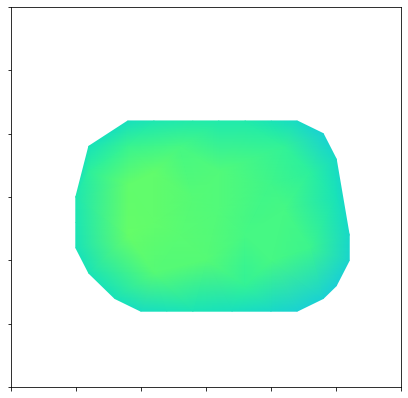

 50%|██████████████████████████████████▎                                  | 249/500 [01:18<02:07,  1.97it/s, corr=0.38]

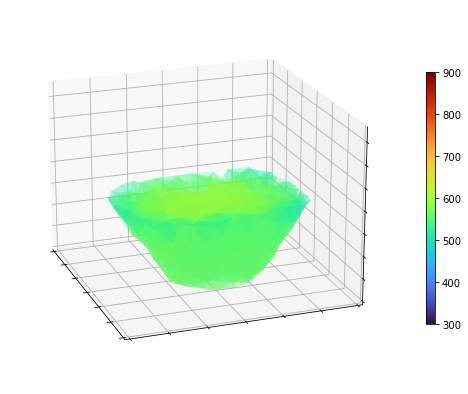

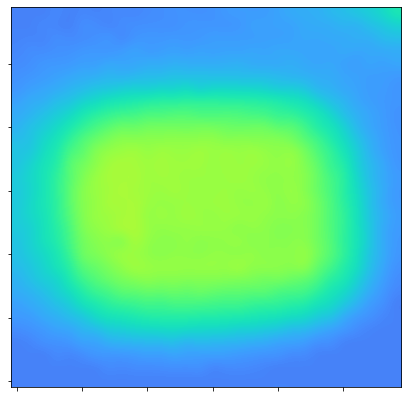

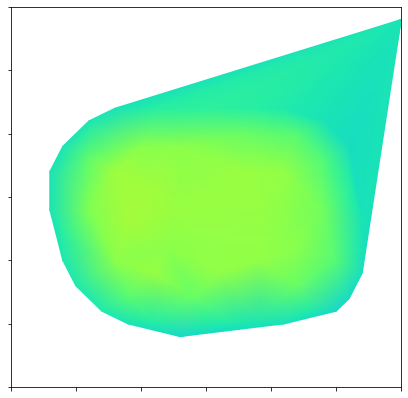

 60%|████████████████████████████████████████▋                           | 299/500 [01:45<01:45,  1.91it/s, corr=0.442]

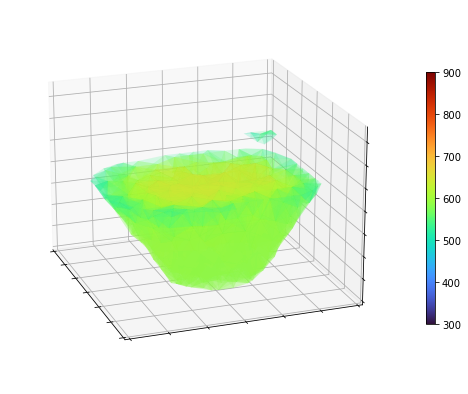

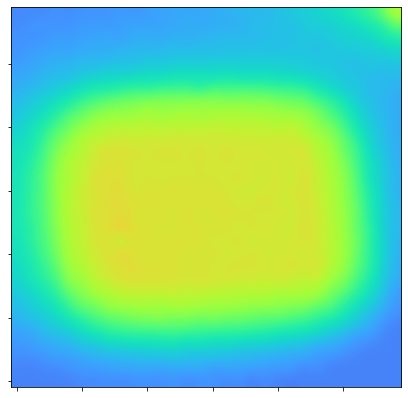

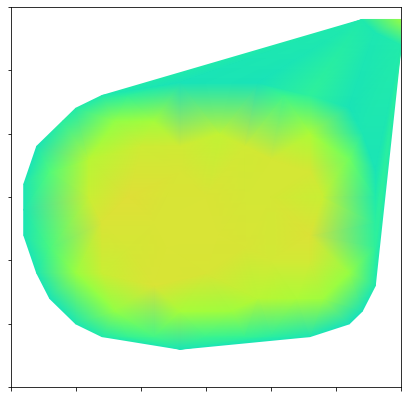

 70%|███████████████████████████████████████████████▍                    | 349/500 [02:22<01:50,  1.37it/s, corr=0.476]

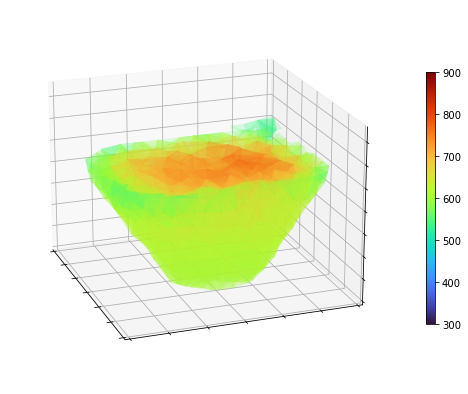

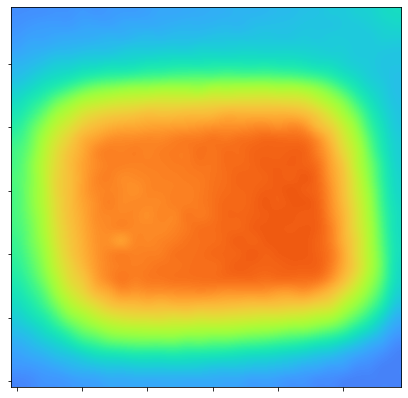

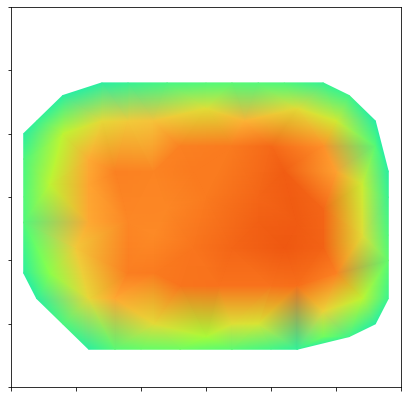

 80%|██████████████████████████████████████████████████████▎             | 399/500 [03:11<01:44,  1.04s/it, corr=0.431]

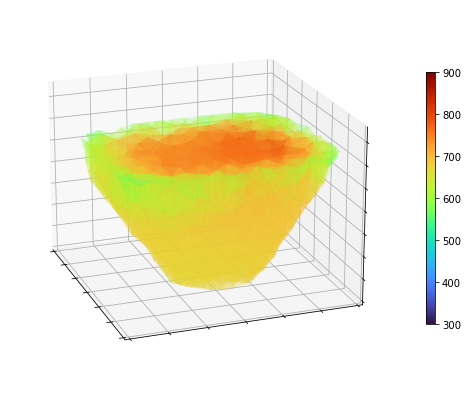

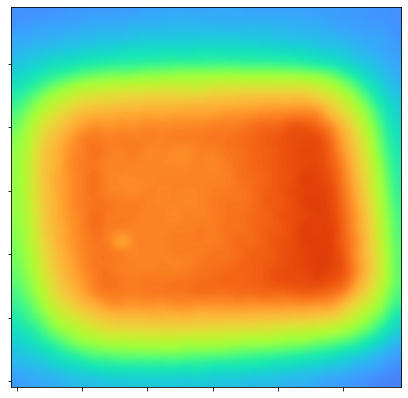

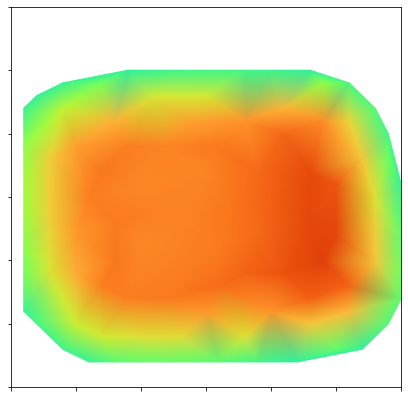

 90%|█████████████████████████████████████████████████████████████       | 449/500 [04:12<00:59,  1.17s/it, corr=0.395]

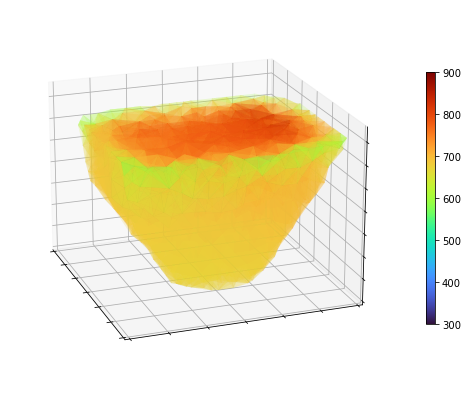

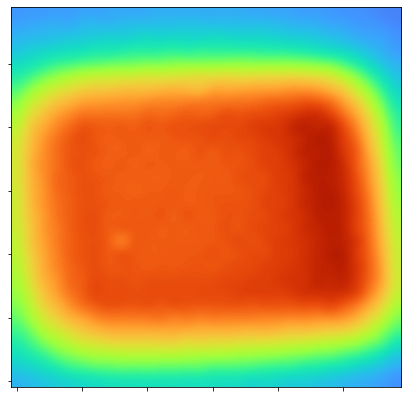

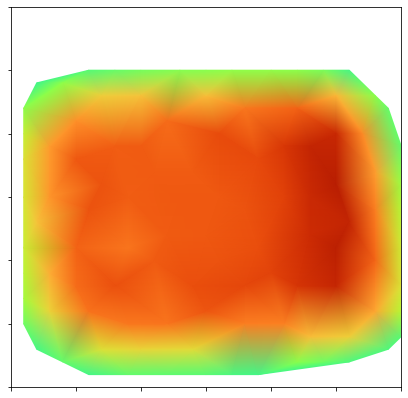

100%|███████████████████████████████████████████████████████████████████▊| 499/500 [05:23<00:01,  1.36s/it, corr=0.362]

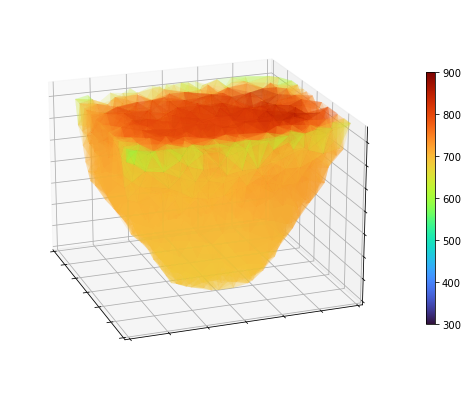

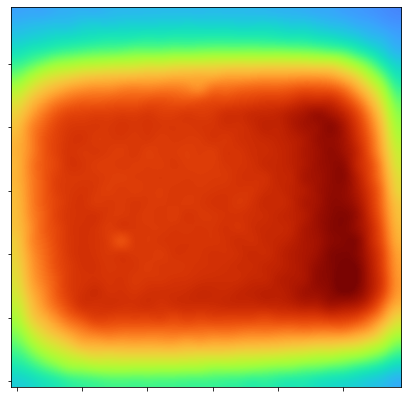

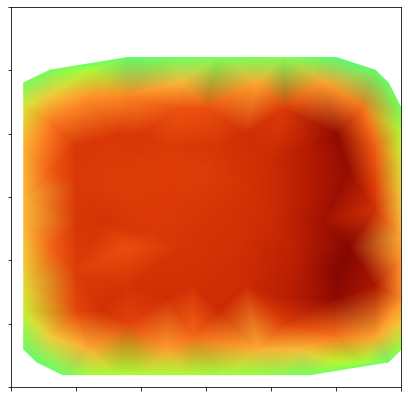

100%|████████████████████████████████████████████████████████████████████| 500/500 [05:27<00:00,  1.52it/s, corr=0.362]


In [15]:
correlations = develop_layers(model)

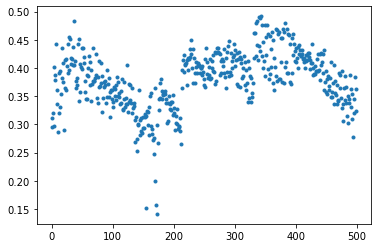

In [9]:
plt.scatter(np.arange(len(correlations)),correlations,marker='.')
plt.savefig('correlations.svg',bbox_inches='tight',format='svg')
plt.show()